# Latest Refresh
## FloodNet NYC Tutorial
Author: Mark Bauer

# Summary
FloodNet refreshes its NYC Open Data datasets roughly every two weeks. In this notebook, we look at the flood events added in the most recent refresh: how many there are, when the flooding happened, and how the new events rank against every event on record.

# Import Libraries

In [69]:
# Libraries
# Standard library
import json
from pathlib import Path

# Third-party
import matplotlib
import matplotlib.pyplot as plt
import polars as pl

# Custom FloodNet functions
import floodnet

In [70]:
# Print versions of packages for reproducibility
libraries = {
    "polars": pl.__version__,
    "matplotlib": matplotlib.__version__,
}

for name, version in libraries.items():
    print(f"{name:10s} {version}")

polars     1.38.1
matplotlib 3.10.8


# Refresh Window
Every row on NYC Open Data carries a hidden `:created_at` timestamp. When we download the data in [00-download-data.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/00-download-data.ipynb), the manifest records two of these timestamps:

- `latest_created_at`: the newest row timestamp as of the download
- `previous_created_at`: what `latest_created_at` was before the most recent refresh

Rows created after `previous_created_at` are the rows the most recent refresh added.

In [71]:
# Flood Events dataset
dataset_id = "aq7i-eu5q"

# Read the watermarks for this dataset from the manifest
manifest = json.loads(Path("data/manifest.json").read_text())["datasets"]
dataset_record = {d["dataset_id"]: d for d in manifest}[dataset_id]

previous_created_at = dataset_record["previous_created_at"]
latest_created_at = dataset_record["latest_created_at"]

print(f"Previous refresh:  {previous_created_at}")
print(f"Latest refresh:    {latest_created_at}")

Previous refresh:  2026-09-01T13:00:14.039Z
Latest refresh:    2026-09-15T13:00:14.878Z


# Download New Flood Events

In [72]:
# Flood events published after the previous refresh
new_df = floodnet.download_new_records(dataset_id, since=previous_created_at)

print(f"Events added: {new_df.height:,}")
print(f"Sensors with new events: {new_df['sensor_id'].n_unique():,}")

https://data.cityofnewyork.us/resource/aq7i-eu5q.csv?%24%24exclude_system_fields=false&%24where=%3Acreated_at+%3E+%272026-09-01T13%3A00%3A14.039Z%27&%24limit=500000

Events added: 86
Sensors with new events: 33


# When Did the New Events Occur?
A refresh can add recent floods as well as older events that were only just processed. The date range of `flood_start_time` (UTC) shows which kind of events this batch contains.

In [73]:
# Date range of the new events
new_df.select(
    pl.col("flood_start_time").min().alias("earliest_start"),
    pl.col("flood_start_time").max().alias("latest_start"),
)

earliest_start,latest_start
datetime[μs],datetime[μs]
2023-09-29 07:23:34,2026-09-08 00:14:50


## New Events per Day
Counting new events by start date shows which storm days produced them. We plot the 30 days leading up to the latest new event, so a few much older events don't stretch the axis.

Events older than the plotted window: 1


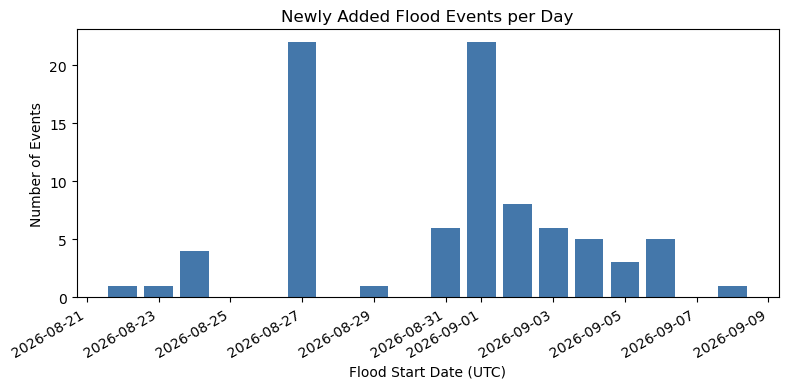

In [74]:
# Keep events within 30 days of the latest new event
window_start = new_df["flood_start_time"].max() - pl.duration(days=30)
recent_df = new_df.filter(pl.col("flood_start_time") >= window_start)

print(f"Events older than the plotted window: {new_df.height - recent_df.height}")

# Count new events per day
daily_df = (
    recent_df.group_by(pl.col("flood_start_time").dt.date().alias("date"))
    .len()
    .sort("date")
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(daily_df["date"], daily_df["len"], color=floodnet.COLORBLIND_PALETTE[0])

ax.set_title("Newly Added Flood Events per Day")
ax.set_xlabel("Flood Start Date (UTC)")
ax.set_ylabel("Number of Events")
fig.autofmt_xdate(rotation=30, ha="right")

fig.tight_layout()

# Where Did the New Events Occur?
We join the new events to the sensor metadata to count them by borough and by whether the sensor is tidally influenced. Tidal sensors flood with high tides, while non-tidal sensors flood mostly from rainfall.

In [75]:
# Read in sensor metadata
metadata_df = pl.read_csv("data/sensor-metadata.csv", try_parse_dates=True)

# Attach borough and tidal influence to each new event
new_meta_df = new_df.join(
    metadata_df.select("sensor_id", "borough", "tidally_influenced"),
    on="sensor_id",
    how="left",
)

# New events by borough
new_meta_df.group_by("borough").len().sort("len", descending=True)

borough,len
str,u32
"""Queens""",32
"""Staten Island""",24
"""Bronx""",22
"""Brooklyn""",8


In [76]:
# New events by tidal influence
new_meta_df.group_by("tidally_influenced").len().sort("len", descending=True)

tidally_influenced,len
str,u32
"""Yes""",49
"""No""",37


## Sensors with the Most New Events
Frequency and depth tell different stories: the sensors that flooded most often are not always the ones that flooded deepest. Note that some locations have more than one sensor, e.g. `Q - Beach 84 St` and `Q - Beach 84 St (2)`, and these are counted separately.

In [77]:
# Top 10 sensors by number of new events
(
    new_meta_df.group_by("sensor_name", "borough", "tidally_influenced")
    .agg(
        pl.len().alias("new_events"),
        pl.col("max_depth_inches").max().alias("max_depth_inches"),
    )
    .sort("new_events", descending=True)
    .head(10)
)

sensor_name,borough,tidally_influenced,new_events,max_depth_inches
str,str,str,u32,f64
"""Q - Beach 84 St""","""Queens""","""Yes""",11,6.3
"""BX - Ditmars St/Hunter Ave 2""","""Bronx""","""Yes""",10,9.29
"""Q - Beach 84 St (2)""","""Queens""","""Yes""",7,6.02
"""BX - Tibbett Ave/W 234th St""","""Bronx""","""No""",6,1.54
"""BK - Brighton 6th St/Ocean Vie…","""Brooklyn""","""No""",4,2.48
"""Q - Norton Dr/ Westbourne Ave""","""Queens""","""Yes""",4,2.4
"""Q - Huxley St/Craft Ave""","""Queens""","""No""",3,2.05
"""SI - Boundary Ave/Hamden Ave""","""Staten Island""","""Yes""",3,10.91
"""SI - Haven Ave/ Adam Ave""","""Staten Island""","""No""",2,7.68


# How Do the New Events Rank?
Below, we rank every flood event on record by max depth and then keep only the new ones. A rank of 1 means this refresh brought in the deepest flood event FloodNet has ever measured.

Flood events have no ID column, so we match on `sensor_id` and `flood_start_time`, which together identify an event.

In [78]:
# Read in all flood events
events_df = pl.read_csv(
    "data/flood-events.csv",
    # some columns have sparse data, need to expand the row count
    infer_schema_length=100_000,
    try_parse_dates=True,
)

print(f"Events on record: {events_df.height:,}")

Events on record: 3,269


In [79]:
# Rank all flood events by max depth (1 = deepest on record)
ranked_df = events_df.with_columns(
    pl.col("max_depth_inches")
        .rank(method="min", descending=True)
        .cast(pl.Int32)
        .alias("depth_rank")
)

# An event is identified by its sensor and start time
event_key = ["sensor_id", "flood_start_time"]

# Columns in preview table
preview_cols = [
    "sensor_name", "flood_start_time", "max_depth_inches", "duration_mins"
]

# Keep only the newly added events
new_ranked_df = (
    ranked_df.join(new_df.select(event_key), on=event_key, how="inner")
    .sort("depth_rank")
)

new_ranked_df.select(["depth_rank"] + preview_cols).head(10)

depth_rank,sensor_name,flood_start_time,max_depth_inches,duration_mins
i32,str,datetime[μs],f64,f64
184,"""SI - Minthorne St/ Victory Blv…",2026-09-01 22:24:42,13.43,177.12
267,"""SI - Ridgewood Ave/Arthur Kill…",2026-08-27 16:42:57,11.65,67.98
317,"""SI - Boundary Ave/Hamden Ave""",2026-08-27 16:50:10,10.91,482.93
357,"""SI - Minthorne St/ Victory Blv…",2026-08-27 20:25:57,10.24,175.0
379,"""SI - Grimsby St/ Mapleton Ave""",2026-08-27 16:57:04,10.0,246.97
439,"""BX - Ditmars St/Hunter Ave 2""",2026-09-02 18:02:40,9.29,196.99
442,"""BK - Hoyt St/5th St""",2023-09-29 07:23:34,9.25,812.31
467,"""SI - Cassidy Pl/Lafayette Ave""",2026-08-27 20:24:15,8.98,43.99
468,"""SI - Bay St/Front St""",2026-09-01 22:30:40,8.94,115.96


# Deepest New Event
We plot the flood profile (depth over time) of the deepest newly added event. Times are in UTC.

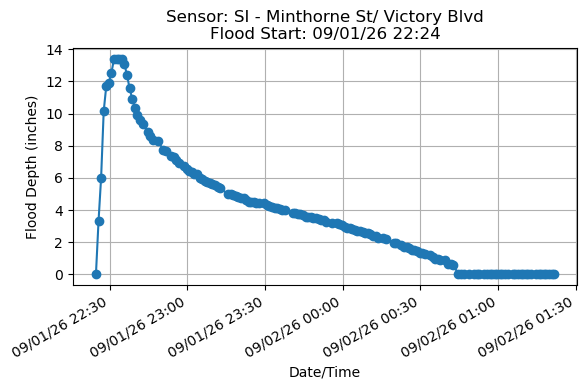

In [80]:
# Top-ranked new event
fig, ax = floodnet.plot_flood_event(
    new_ranked_df.head(1),
    start_col="flood_start_time",
)

To refresh the data, rerun [00-download-data.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/00-download-data.ipynb). For rankings across every event and sensor, see [02-sensor-rankings.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/02-sensor-rankings.ipynb).